# Swin Transformer — LCC-FASD (Google Colab)

Notebook propre et organisé pour :

- téléchargement **automatique** du dataset `LCC-FASD`
- analyse du **déséquilibre** des classes
- entraînement de **5 stratégies**
- sauvegarde complète des **outputs**
- calcul des **métriques**
- génération de **graphes** (accuracy, loss, F1, confusion matrix)

## Stratégies incluses
1. `freeze_all`
2. `1_finetune`
3. `2_finetune`
4. `3_finetune`
5. `finetune_all`

## Recommandation
Pour ce dataset déséquilibré, commence par :
- `1_finetune`
- puis `2_finetune`

Ensuite compare avec :
- `3_finetune`
- `finetune_all`
- `freeze_all`


In [1]:
# =========================
# 1) Installation
# =========================
!pip install -q transformers timm kagglehub scikit-learn seaborn imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.7 MB/s eta 0:00:00


In [2]:
# =========================
# 2) Imports + seed
# =========================
import os
import json
import math
import random
import shutil
import zipfile
import warnings
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
import imagehash

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import SwinForImageClassification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, balanced_accuracy_score
)

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [3]:
# =========================
# 3) Configuration générale
# =========================
CONFIG = {
    "kaggle_dataset": "faber24/lcc-fasd",
    "model_name": "microsoft/swin-base-patch4-window7-224-in22k",
    "num_classes": 2,
    "image_size": 224,
    "batch_size": 16,
    "num_epochs": 15,
    "num_workers": 2,
    "weight_decay": 1e-4,
    "label_smoothing": 0.05,
    "grad_clip": 1.0,
    "early_stopping_patience": 4,
    "use_class_weights": True,
    "save_root": "/content/outputs_swin_lccfasd",
    "drive_backup_root": "/content/drive/MyDrive/outputs_swin_lccfasd",
    "save_to_drive_after_each_strategy": True
}

SAVE_ROOT = Path(CONFIG["save_root"])
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
print('Save root:', SAVE_ROOT)


Save root: /content/outputs_swin_lccfasd


## 4) Téléchargement automatique du dataset

Cette cellule télécharge automatiquement le dataset depuis KaggleHub puis trouve
automatiquement les dossiers `train`, `val`, `test`, même si le dataset est imbriqué dans un sous-dossier.


In [6]:
# =========================
# 4) Téléchargement automatique du dataset + mapping correct LCC_FASD
# =========================
!pip install -q kagglehub
import kagglehub
from pathlib import Path
print("Téléchargement automatique du dataset...")

from pathlib import Path
import os

download_path = Path(kagglehub.dataset_download(CONFIG["kaggle_dataset"]))
print("Dataset téléchargé dans :", download_path)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_recursive(folder: Path):
    if not folder.exists():
        return 0
    return sum(1 for f in folder.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXTS)

def show_tree(root: Path, max_depth=3):
    print(f"\nAperçu de la structure : {root}\n")
    for path, dirs, files in os.walk(root):
        rel = Path(path).relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        indent = "    " * depth
        print(f"{indent}{Path(path).name}/")

def find_lcc_fasd_splits(root: Path):
    root = Path(root)

    # on cherche un dossier contenant les 3 splits officiels LCC_FASD
    all_dirs = [root] + [p for p in root.rglob("*") if p.is_dir()]

    for d in all_dirs:
        children = {x.name: x for x in d.iterdir() if x.is_dir()}

        expected = {
            "LCC_FASD_training",
            "LCC_FASD_development",
            "LCC_FASD_evaluation"
        }

        if expected.issubset(set(children.keys())):
            train_dir = children["LCC_FASD_training"]
            val_dir   = children["LCC_FASD_development"]
            test_dir  = children["LCC_FASD_evaluation"]

            # vérifier qu'il y a bien real/spoof dans chaque split
            for split_name, split_dir in {
                "train": train_dir,
                "val": val_dir,
                "test": test_dir
            }.items():
                subdirs = {x.name.lower() for x in split_dir.iterdir() if x.is_dir()}
                if not {"real", "spoof"}.issubset(subdirs):
                    raise FileNotFoundError(
                        f"Le dossier {split_name} trouvé ({split_dir}) ne contient pas real/spoof."
                    )

            return {
                "root": d,
                "train": train_dir,
                "val": val_dir,
                "test": test_dir
            }

    show_tree(root)
    raise FileNotFoundError(
        "Impossible de trouver la structure officielle LCC_FASD "
        "(LCC_FASD_training / LCC_FASD_development / LCC_FASD_evaluation)."
    )

SPLITS = find_lcc_fasd_splits(download_path)

print("\nStructure détectée automatiquement :")
for k, v in SPLITS.items():
    print(f"{k:>5} -> {v}")

print("\nNombre d'images détectées :")
for split in ["train", "val", "test"]:
    print(f"{split:>5} : {count_images_recursive(SPLITS[split])}")

Téléchargement automatique du dataset...
Using Colab cache for faster access to the 'lcc-fasd' dataset.
Dataset téléchargé dans : /kaggle/input/lcc-fasd

Structure détectée automatiquement :
 root -> /kaggle/input/lcc-fasd/LCC_FASD
train -> /kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_training
  val -> /kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_development
 test -> /kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_evaluation

Nombre d'images détectées :
train : 8299
  val : 2948
 test : 7580


In [7]:
# =========================
# 5) Vérification visuelle de la structure
# =========================
print("Contenu du dossier racine détecté :")
for item in sorted(SPLITS["root"].iterdir()):
    mark = "📁" if item.is_dir() else "📄"
    print(mark, item.name)

Contenu du dossier racine détecté :
📁 LCC_FASD_development
📁 LCC_FASD_evaluation
📁 LCC_FASD_training


## 6) Audit qualité du dataset

Cette partie vérifie que le dataset est **bien réalisé** avant l'entraînement :

- images lisibles
- dimensions minimales correctes
- doublons exacts
- doublons visuels potentiels entre `train / val / test`
- déséquilibre des classes

⚠️ Important : l'augmentation dans `train_tf` est **online**. Elle ne crée pas plus de fichiers dans le dataset ; elle rend seulement l'entraînement plus varié.


In [8]:
# =========================
# 6) Audit qualité du dataset
# =========================
def audit_split_images(split_dir: Path, split_name: str, min_size=32, max_examples=5):
    rows = []
    errors = []
    exact_hashes = {}

    for img_path in sorted(split_dir.rglob("*")):
        if not img_path.is_file() or img_path.suffix.lower() not in IMG_EXTS:
            continue

        try:
            file_bytes = img_path.read_bytes()
            exact_hash = hashlib.md5(file_bytes).hexdigest()

            with Image.open(img_path) as im:
                im.verify()

            with Image.open(img_path) as im:
                im = im.convert("RGB")
                width, height = im.size
                mode = im.mode
                p_hash = str(imagehash.phash(im.resize((224, 224))))

            label_name = img_path.parent.name.lower()

            rows.append({
                "split": split_name,
                "path": str(img_path),
                "class_name": label_name,
                "width": width,
                "height": height,
                "min_side": min(width, height),
                "mode": mode,
                "exact_hash": exact_hash,
                "phash": p_hash,
                "too_small": min(width, height) < min_size,
            })

            exact_hashes.setdefault(exact_hash, []).append(str(img_path))

        except Exception as e:
            errors.append({
                "split": split_name,
                "path": str(img_path),
                "error": str(e)
            })

    df = pd.DataFrame(rows)
    err_df = pd.DataFrame(errors)

    dup_exact = []
    for h, paths in exact_hashes.items():
        if len(paths) > 1:
            dup_exact.append({
                "exact_hash": h,
                "count": len(paths),
                "paths": paths[:max_examples]
            })

    dup_exact_df = pd.DataFrame(dup_exact)
    return df, err_df, dup_exact_df


def find_cross_split_visual_duplicates(meta_df: pd.DataFrame):
    if meta_df.empty:
        return pd.DataFrame()

    g = meta_df.groupby("phash").agg(
        n=("path", "count"),
        splits=("split", lambda x: sorted(set(x))),
        paths=("path", lambda x: list(x)[:6])
    ).reset_index()

    g["n_splits"] = g["splits"].apply(len)
    g = g[(g["n"] > 1) & (g["n_splits"] > 1)].sort_values(
        ["n_splits", "n"], ascending=False
    )
    return g


def summarize_dataset_quality(split_tables):
    meta_df = pd.concat([x[0] for x in split_tables.values()], ignore_index=True) if split_tables else pd.DataFrame()
    err_df = pd.concat([x[1] for x in split_tables.values()], ignore_index=True) if split_tables else pd.DataFrame()
    exact_dup_df = pd.concat([x[2] for x in split_tables.values()], ignore_index=True) if split_tables else pd.DataFrame()
    cross_dup_df = find_cross_split_visual_duplicates(meta_df)

    if not meta_df.empty:
        class_summary = meta_df.groupby(["split", "class_name"]).size().reset_index(name="count")
        size_summary = meta_df.groupby("split").agg(
            n_images=("path", "count"),
            min_width=("width", "min"),
            min_height=("height", "min"),
            median_width=("width", "median"),
            median_height=("height", "median"),
            too_small=("too_small", "sum")
        ).reset_index()
    else:
        class_summary = pd.DataFrame()
        size_summary = pd.DataFrame()

    audit_report = {
        "n_total_images": int(len(meta_df)) if not meta_df.empty else 0,
        "n_corrupt_images": int(len(err_df)) if not err_df.empty else 0,
        "n_exact_duplicate_groups": int(len(exact_dup_df)) if not exact_dup_df.empty else 0,
        "n_cross_split_visual_duplicate_groups": int(len(cross_dup_df)) if not cross_dup_df.empty else 0,
    }

    return meta_df, err_df, exact_dup_df, cross_dup_df, class_summary, size_summary, audit_report


split_audits = {}
for split_name in ["train", "val", "test"]:
    print(f"\nAudit du split : {split_name}")
    split_audits[split_name] = audit_split_images(SPLITS[split_name], split_name)

META_DF, ERR_DF, EXACT_DUP_DF, CROSS_DUP_DF, CLASS_SUMMARY_DF, SIZE_SUMMARY_DF, AUDIT_REPORT = summarize_dataset_quality(split_audits)

print("\nRésumé audit dataset :")
print(json.dumps(AUDIT_REPORT, indent=2))

if not CLASS_SUMMARY_DF.empty:
    display(CLASS_SUMMARY_DF)

if not SIZE_SUMMARY_DF.empty:
    display(SIZE_SUMMARY_DF)

if not ERR_DF.empty:
    print("\nImages corrompues détectées :")
    display(ERR_DF.head(20))
else:
    print("\nAucune image corrompue détectée.")

if not EXACT_DUP_DF.empty:
    print("\nDoublons exacts détectés :")
    display(EXACT_DUP_DF.head(20))
else:
    print("\nAucun doublon exact détecté.")

if not CROSS_DUP_DF.empty:
    print("\nAttention : doublons visuels potentiels entre splits détectés (risque de fuite de données).")
    display(CROSS_DUP_DF.head(20))
else:
    print("\nAucun doublon visuel inter-splits détecté.")

pd.DataFrame([AUDIT_REPORT]).to_csv(SAVE_ROOT / "dataset_audit_summary.csv", index=False)
META_DF.to_csv(SAVE_ROOT / "dataset_metadata.csv", index=False)

if not ERR_DF.empty:
    ERR_DF.to_csv(SAVE_ROOT / "dataset_corrupt_images.csv", index=False)

if not EXACT_DUP_DF.empty:
    EXACT_DUP_DF.to_csv(SAVE_ROOT / "dataset_exact_duplicates.csv", index=False)

if not CROSS_DUP_DF.empty:
    CROSS_DUP_DF.to_csv(SAVE_ROOT / "dataset_cross_split_visual_duplicates.csv", index=False)


Audit du split : train

Audit du split : val

Audit du split : test

Résumé audit dataset :
{
  "n_total_images": 18827,
  "n_corrupt_images": 0,
  "n_exact_duplicate_groups": 30,
  "n_cross_split_visual_duplicate_groups": 93
}


,split,class_name,count
0,test,real,314
1,test,spoof,7266
2,train,real,1223
3,train,spoof,7076
4,val,real,405
5,val,spoof,2543


,split,n_images,min_width,min_height,median_width,median_height,too_small
0,test,7580,59,59,475.0,475.0,0
1,train,8299,65,65,495.0,495.0,0
2,val,2948,76,76,497.0,497.0,0



Aucune image corrompue détectée.

Doublons exacts détectés :


,exact_hash,count,paths
0,16238b88d403a9c5a0642996f7bdf0c4,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
1,f9aacc4ca1cfe5f7ceab352b57b49d8f,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
2,5070a0b613ce86664d28fc8c3c734ab6,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
3,5f1a7b6bf1b15227e49df30c802025d4,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
4,96ad216b6dd992a62426dc76ddf1b9ba,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
5,c47d493bb114195394ec40b74f45e03a,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
6,6563b7b67250919b49faff8af223d7fc,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
7,c0b4f19d8d6d96d68a27df64c33cfa97,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
8,f3bfaba4f6ae14344076c28d9b501120,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...
9,43d6644f84d89e1e220c2bc7c1bbfa27,2,[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...



Attention : doublons visuels potentiels entre splits détectés (risque de fuite de données).


,phash,n,splits,paths,n_splits
17080,ff95f4a638383032,27,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
16168,faa22193b73133c3,25,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
16167,faa22193b7313393,22,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
6929,afbce4c2606072f6,10,"[test, train]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
8325,bf2b4ae545ac03b2,9,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
12022,daf261e1e76464c4,9,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
8324,bf2b4ae545ac01f2,7,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
12017,daf261e1e66464ca,6,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
17095,ff9df4a638382032,6,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2
12018,daf261e1e66464cc,5,"[train, val]",[/kaggle/input/lcc-fasd/LCC_FASD/LCC_FASD_trai...,2


In [9]:
# =========================
# 6-bis) Nettoyage du train contre la fuite vers val/test
# =========================
from pathlib import Path
import shutil

CLEAN_ROOT = SAVE_ROOT / "clean_dataset"
CLEAN_TRAIN = CLEAN_ROOT / "train"
CLEAN_VAL   = CLEAN_ROOT / "val"
CLEAN_TEST  = CLEAN_ROOT / "test"

for d in [CLEAN_TRAIN, CLEAN_VAL, CLEAN_TEST]:
    d.mkdir(parents=True, exist_ok=True)

def build_clean_train_from_audit(meta_df, original_train_dir, original_val_dir, original_test_dir,
                                 clean_train_dir, clean_val_dir, clean_test_dir):
    meta_df = meta_df.copy()

    # phash présents dans val/test
    forbidden_phash = set(
        meta_df[meta_df["split"].isin(["val", "test"])]["phash"].dropna().unique().tolist()
    )

    train_meta = meta_df[meta_df["split"] == "train"].copy()

    # on retire du train les images dont le phash existe déjà dans val/test
    clean_train_meta = train_meta[~train_meta["phash"].isin(forbidden_phash)].copy()

    removed_train_meta = train_meta[train_meta["phash"].isin(forbidden_phash)].copy()

    print(f"Train original : {len(train_meta)} images")
    print(f"Train nettoyé  : {len(clean_train_meta)} images")
    print(f"Train supprimé : {len(removed_train_meta)} images")

    # copie train nettoyé
    for _, row in clean_train_meta.iterrows():
        src = Path(row["path"])
        cls = row["class_name"]
        dst_dir = clean_train_dir / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst_dir / src.name)

    # copie val intact
    for img_path in Path(original_val_dir).rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            rel = img_path.relative_to(original_val_dir)
            dst = clean_val_dir / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dst)

    # copie test intact
    for img_path in Path(original_test_dir).rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            rel = img_path.relative_to(original_test_dir)
            dst = clean_test_dir / rel
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dst)

    removed_train_meta.to_csv(CLEAN_ROOT / "removed_from_train_due_to_leakage.csv", index=False)
    clean_train_meta.to_csv(CLEAN_ROOT / "clean_train_metadata.csv", index=False)

    return clean_train_meta, removed_train_meta

CLEAN_TRAIN_META, REMOVED_TRAIN_META = build_clean_train_from_audit(
    META_DF,
    SPLITS["train"],
    SPLITS["val"],
    SPLITS["test"],
    CLEAN_TRAIN,
    CLEAN_VAL,
    CLEAN_TEST
)

Train original : 8299 images
Train nettoyé  : 8208 images
Train supprimé : 91 images


In [10]:
# =========================
# 6-ter) Redéfinir SPLITS vers le dataset nettoyé
# =========================
SPLITS = {
    "root": CLEAN_ROOT,
    "train": CLEAN_TRAIN,
    "val": CLEAN_VAL,
    "test": CLEAN_TEST,
}

print("Nouveaux splits :")
for k in ["train", "val", "test"]:
    n_imgs = sum(1 for f in SPLITS[k].rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXTS)
    print(k, "->", SPLITS[k], ":", n_imgs, "images")

Nouveaux splits :
train -> /content/outputs_swin_lccfasd/clean_dataset/train : 8208 images
val -> /content/outputs_swin_lccfasd/clean_dataset/val : 2948 images
test -> /content/outputs_swin_lccfasd/clean_dataset/test : 7580 images


In [11]:
# =========================
# 6-quater) Ré-audit du clean_dataset
# =========================
CLEAN_SPLITS = {
    "train": SPLITS["train"],
    "val": SPLITS["val"],
    "test": SPLITS["test"],
}

clean_split_audits = {}
for split_name in ["train", "val", "test"]:
    print(f"\nRé-audit du split clean : {split_name}")
    clean_split_audits[split_name] = audit_split_images(CLEAN_SPLITS[split_name], split_name)

(
    CLEAN_META_DF,
    CLEAN_ERR_DF,
    CLEAN_EXACT_DUP_DF,
    CLEAN_CROSS_DUP_DF,
    CLEAN_CLASS_SUMMARY_DF,
    CLEAN_SIZE_SUMMARY_DF,
    CLEAN_AUDIT_REPORT
) = summarize_dataset_quality(clean_split_audits)

print("\nRésumé audit CLEAN dataset :")
print(json.dumps(CLEAN_AUDIT_REPORT, indent=2))

if not CLEAN_CLASS_SUMMARY_DF.empty:
    display(CLEAN_CLASS_SUMMARY_DF)

if not CLEAN_SIZE_SUMMARY_DF.empty:
    display(CLEAN_SIZE_SUMMARY_DF)

if not CLEAN_ERR_DF.empty:
    print("\nImages corrompues détectées dans clean_dataset :")
    display(CLEAN_ERR_DF.head(20))
else:
    print("\nAucune image corrompue dans clean_dataset.")

if not CLEAN_EXACT_DUP_DF.empty:
    print("\nDoublons exacts restants dans clean_dataset :")
    display(CLEAN_EXACT_DUP_DF.head(20))
else:
    print("\nAucun doublon exact dans clean_dataset.")

if not CLEAN_CROSS_DUP_DF.empty:
    print("\nDoublons visuels inter-splits restants dans clean_dataset :")
    display(CLEAN_CROSS_DUP_DF.head(20))
else:
    print("\nAucun doublon visuel inter-splits dans clean_dataset.")

pd.DataFrame([CLEAN_AUDIT_REPORT]).to_csv(SAVE_ROOT / "clean_dataset_audit_summary.csv", index=False)
CLEAN_META_DF.to_csv(SAVE_ROOT / "clean_dataset_metadata.csv", index=False)

if not CLEAN_ERR_DF.empty:
    CLEAN_ERR_DF.to_csv(SAVE_ROOT / "clean_dataset_corrupt_images.csv", index=False)

if not CLEAN_EXACT_DUP_DF.empty:
    CLEAN_EXACT_DUP_DF.to_csv(SAVE_ROOT / "clean_dataset_exact_duplicates.csv", index=False)

if not CLEAN_CROSS_DUP_DF.empty:
    CLEAN_CROSS_DUP_DF.to_csv(SAVE_ROOT / "clean_dataset_cross_split_visual_duplicates.csv", index=False)


Ré-audit du split clean : train

Ré-audit du split clean : val

Ré-audit du split clean : test

Résumé audit CLEAN dataset :
{
  "n_total_images": 18736,
  "n_corrupt_images": 0,
  "n_exact_duplicate_groups": 30,
  "n_cross_split_visual_duplicate_groups": 25
}


,split,class_name,count
0,test,real,314
1,test,spoof,7266
2,train,real,1173
3,train,spoof,7035
4,val,real,405
5,val,spoof,2543


,split,n_images,min_width,min_height,median_width,median_height,too_small
0,test,7580,59,59,475.0,475.0,0
1,train,8208,65,65,494.0,494.0,0
2,val,2948,76,76,497.0,497.0,0



Aucune image corrompue dans clean_dataset.

Doublons exacts restants dans clean_dataset :


,exact_hash,count,paths
0,16238b88d403a9c5a0642996f7bdf0c4,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
1,f9aacc4ca1cfe5f7ceab352b57b49d8f,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
2,5070a0b613ce86664d28fc8c3c734ab6,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
3,5f1a7b6bf1b15227e49df30c802025d4,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
4,96ad216b6dd992a62426dc76ddf1b9ba,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
5,c47d493bb114195394ec40b74f45e03a,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
6,6563b7b67250919b49faff8af223d7fc,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
7,c0b4f19d8d6d96d68a27df64c33cfa97,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
8,f3bfaba4f6ae14344076c28d9b501120,2,[/content/outputs_swin_lccfasd/clean_dataset/t...
9,43d6644f84d89e1e220c2bc7c1bbfa27,2,[/content/outputs_swin_lccfasd/clean_dataset/t...



Doublons visuels inter-splits restants dans clean_dataset :


,phash,n,splits,paths,n_splits
8170,bddaf28542e025e6,3,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
640,8a0fed2aa7252df0,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
991,8a8a2ff52d742553,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
995,8a8e2ff52d742551,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
1493,8b8a2ef57a752542,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
1494,8b8a2ef57e742152,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
1500,8b8e2ff56c742542,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
2567,93e04a3775012f77,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
2568,93e04a7745052ff5,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2
2569,93e04a77550527f5,2,"[test, val]",[/content/outputs_swin_lccfasd/clean_dataset/v...,2


## 6) Dataset + transforms

- augmentation **modérée**
- adaptée au face anti-spoofing
- pas d'augmentation trop agressive


In [12]:
# =========================
# 6) Dataset
# =========================
class LCCFASDDataset(Dataset):
    REAL_NAMES = {"real"}
    SPOOF_NAMES = {"spoof", "fake", "attack"}
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, split_dir: Path, transform=None):
        self.split_dir = Path(split_dir)
        self.transform = transform
        self.samples = []
        self.labels = []

        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split introuvable: {self.split_dir}")

        for cls_dir in sorted(self.split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue

            name = cls_dir.name.lower()
            if name in self.REAL_NAMES:
                label = 0
            elif name in self.SPOOF_NAMES:
                label = 1
            else:
                continue

            for f in cls_dir.rglob("*"):
                if f.is_file() and f.suffix.lower() in self.IMG_EXTS:
                    self.samples.append((f, label))
                    self.labels.append(label)

        if len(self.samples) == 0:
            raise RuntimeError(f"Aucune image trouvée dans {self.split_dir}")

        print(f"{self.split_dir.name}: total={len(self.samples)} | real={self.labels.count(0)} | spoof={self.labels.count(1)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SZ = CONFIG["image_size"]

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(SZ, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.02),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(SZ),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [13]:
# =========================
# 7) Charger les datasets
# =========================
train_ds = LCCFASDDataset(SPLITS["train"], transform=train_tf)
val_ds   = LCCFASDDataset(SPLITS["val"], transform=eval_tf)
test_ds  = LCCFASDDataset(SPLITS["test"], transform=eval_tf)

print("\nTrain distribution:", Counter(train_ds.labels))
print("Val distribution  :", Counter(val_ds.labels))
print("Test distribution :", Counter(test_ds.labels))

train: total=8208 | real=1173 | spoof=7035
val: total=2948 | real=405 | spoof=2543
test: total=7580 | real=314 | spoof=7266

Train distribution: Counter({1: 7035, 0: 1173})
Val distribution  : Counter({1: 2543, 0: 405})
Test distribution : Counter({1: 7266, 0: 314})


## 8) Analyse du déséquilibre des classes

,real,spoof,total,real_pct,spoof_pct,ratio_spoof_real
train,1173.0,7035.0,8208.0,14.290936,85.709064,5.997442
val,405.0,2543.0,2948.0,13.738128,86.261872,6.279012
test,314.0,7266.0,7580.0,4.142480,95.857520,23.140127


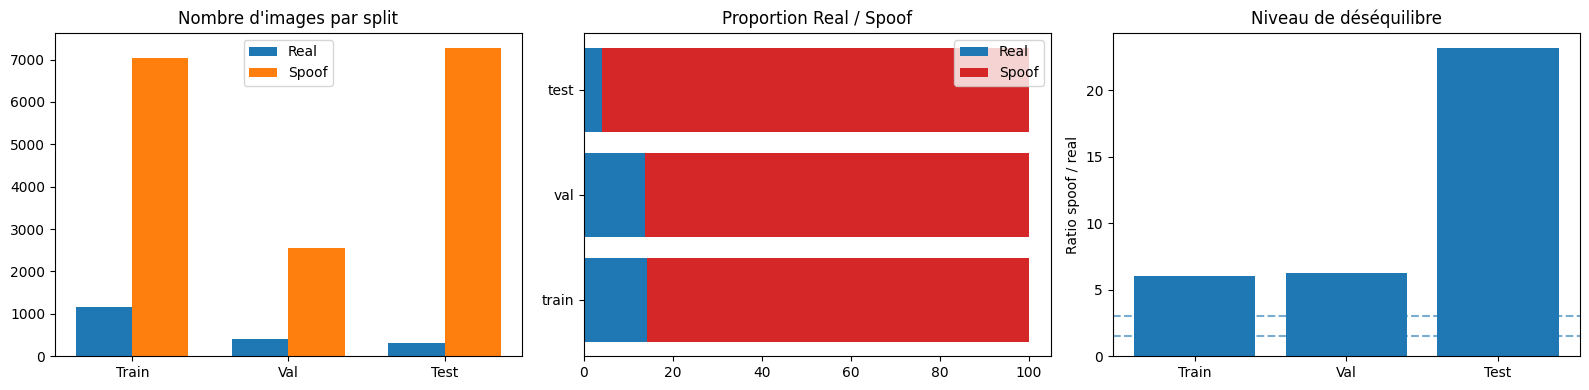

In [14]:
# =========================
# 8) Analyse du déséquilibre
# =========================
def get_split_stats(ds):
    c = Counter(ds.labels)
    real = c.get(0, 0)
    spoof = c.get(1, 0)
    total = real + spoof
    ratio = (spoof / real) if real > 0 else np.nan
    return {
        "real": real,
        "spoof": spoof,
        "total": total,
        "real_pct": 100 * real / total,
        "spoof_pct": 100 * spoof / total,
        "ratio_spoof_real": ratio
    }

stats = {
    "train": get_split_stats(train_ds),
    "val": get_split_stats(val_ds),
    "test": get_split_stats(test_ds)
}
stats_df = pd.DataFrame(stats).T
display(stats_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Nombre d'images
x = np.arange(3)
real_vals = [stats[s]["real"] for s in ["train", "val", "test"]]
spoof_vals = [stats[s]["spoof"] for s in ["train", "val", "test"]]
labels = ["Train", "Val", "Test"]

axes[0].bar(x - 0.18, real_vals, width=0.36, label="Real")
axes[0].bar(x + 0.18, spoof_vals, width=0.36, label="Spoof")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title("Nombre d'images par split")
axes[0].legend()

# Proportions
for i, s in enumerate(["train", "val", "test"]):
    axes[1].barh(i, stats[s]["real_pct"], color="C0", label="Real" if i == 0 else None)
    axes[1].barh(i, stats[s]["spoof_pct"], left=stats[s]["real_pct"], color="C3", label="Spoof" if i == 0 else None)
axes[1].set_yticks([0,1,2])
axes[1].set_yticklabels(["train", "val", "test"])
axes[1].set_title("Proportion Real / Spoof")
axes[1].legend()

# Ratio
ratios = [stats[s]["ratio_spoof_real"] for s in ["train", "val", "test"]]
axes[2].bar(labels, ratios)
axes[2].axhline(1.5, linestyle="--", alpha=0.6)
axes[2].axhline(3.0, linestyle="--", alpha=0.6)
axes[2].set_title("Niveau de déséquilibre")
axes[2].set_ylabel("Ratio spoof / real")

plt.tight_layout()
plt.show()

## 9) DataLoaders + class weights

Solution idéale choisie dans ce notebook :

- **class weights**
- **label smoothing**
- **early stopping**
- **best model selon Macro F1**
- **augmentation modérée**

Ici, on **n'utilise pas WeightedRandomSampler par défaut** pour éviter une instabilité inutile.


In [15]:
# =========================
# 9) DataLoaders + class weights
# =========================
train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

train_counts = Counter(train_ds.labels)
n_total = len(train_ds.labels)

class_weights = torch.tensor(
    [n_total / (2 * train_counts[i]) for i in range(2)],
    dtype=torch.float32
).to(DEVICE)

print("Class weights:", class_weights)

Class weights: tensor([3.4987, 0.5834], device='cuda:0')


In [16]:
# =========================
# 10) WeightedRandomSampler pour équilibrer le train
# =========================
from torch.utils.data import WeightedRandomSampler

train_counts = Counter(train_ds.labels)
class_sample_weights = {cls: 1.0 / count for cls, count in train_counts.items()}
sample_weights = [class_sample_weights[label] for label in train_ds.labels]

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    sampler=train_sampler,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

print("Sampler équilibré activé.")
print("Train counts:", train_counts)
print("Class weights:", class_weights)

Sampler équilibré activé.
Train counts: Counter({1: 7035, 0: 1173})
Class weights: tensor([3.4987, 0.5834], device='cuda:0')


In [17]:
# =========================
# 9-bis) Choix propre de la stratégie d'équilibrage
# =========================
USE_SAMPLER = True
USE_CLASS_WEIGHTS_IN_LOSS = False

if USE_SAMPLER:
    from torch.utils.data import WeightedRandomSampler

    train_counts = Counter(train_ds.labels)
    class_sample_weights = {cls: 1.0 / count for cls, count in train_counts.items()}
    sample_weights = [class_sample_weights[label] for label in train_ds.labels]

    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        sampler=train_sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )

    print("Stratégie utilisée : WeightedRandomSampler")
else:
    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )

    print("Stratégie utilisée : shuffle normal")

if USE_CLASS_WEIGHTS_IN_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print("Loss : CrossEntropy avec class_weights")
else:
    criterion = nn.CrossEntropyLoss()
    print("Loss : CrossEntropy normale")

Stratégie utilisée : WeightedRandomSampler
Loss : CrossEntropy normale


## 10) Fonctions utilitaires du modèle

In [18]:
# =========================
# 10) Utilitaires modèle
# =========================
def load_swin(model_name, num_classes):
    model = SwinForImageClassification.from_pretrained(
        model_name,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )
    return model

def apply_strategy(model, strategy="1_finetune"):
    # Tout geler
    for p in model.parameters():
        p.requires_grad = False

    # Toujours entraîner le classifier
    for p in model.classifier.parameters():
        p.requires_grad = True

    layers = model.swin.encoder.layers

    if strategy == "freeze_all":
        pass

    elif strategy == "1_finetune":
        for p in layers[-1].parameters():
            p.requires_grad = True
        for p in model.swin.layernorm.parameters():
            p.requires_grad = True

    elif strategy == "2_finetune":
        for stage in layers[-2:]:
            for p in stage.parameters():
                p.requires_grad = True
        for p in model.swin.layernorm.parameters():
            p.requires_grad = True

    elif strategy == "3_finetune":
        for stage in layers[-3:]:
            for p in stage.parameters():
                p.requires_grad = True
        for p in model.swin.layernorm.parameters():
            p.requires_grad = True

    elif strategy == "finetune_all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Stratégie inconnue: {strategy}")

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{strategy}: trainable = {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return model

def build_optimizer(model, strategy):
    classifier_params = []
    backbone_params = []

    for name, p in model.named_parameters():
        if p.requires_grad:
            if "classifier" in name:
                classifier_params.append(p)
            else:
                backbone_params.append(p)

    if strategy == "freeze_all":
        lr_backbone = 0.0
        lr_classifier = 1e-4
    elif strategy == "1_finetune":
        lr_backbone = 1e-5
        lr_classifier = 5e-5
    elif strategy == "2_finetune":
        lr_backbone = 8e-6
        lr_classifier = 4e-5
    elif strategy == "3_finetune":
        lr_backbone = 6e-6
        lr_classifier = 3e-5
    elif strategy == "finetune_all":
        lr_backbone = 5e-6
        lr_classifier = 2e-5
    else:
        raise ValueError(strategy)

    groups = []
    if len(backbone_params) > 0:
        groups.append({"params": backbone_params, "lr": lr_backbone})
    if len(classifier_params) > 0:
        groups.append({"params": classifier_params, "lr": lr_classifier})

    optimizer = optim.AdamW(groups, weight_decay=CONFIG["weight_decay"])
    return optimizer

criterion = nn.CrossEntropyLoss(
    weight=class_weights if CONFIG["use_class_weights"] else None,
    label_smoothing=CONFIG["label_smoothing"]
)

In [19]:
# =========================
# 11) Fonctions train / eval
# =========================
def train_one_epoch(model, loader, optimizer, criterion, device, epoch=None, total_epochs=None, strategy=""):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    total_batches = len(loader)

    for step, (images, labels) in enumerate(loader):
        if step % 20 == 0 or step == total_batches - 1:
            prefix = f"[{strategy}] " if strategy else ""
            if epoch is not None and total_epochs is not None:
                print(f"{prefix}Epoch {epoch}/{total_epochs} | Batch {step+1}/{total_batches}")

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images).logits
        loss = criterion(outputs, labels)

        loss.backward()

        if "grad_clip" in CONFIG and CONFIG["grad_clip"] is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds) * 100
    epoch_f1 = f1_score(all_labels, all_preds, average="macro") * 100
    epoch_bacc = balanced_accuracy_score(all_labels, all_preds) * 100

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "f1_macro": epoch_f1,
        "bacc": epoch_bacc
    }

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs).logits
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds) * 100
    prec_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0) * 100
    rec_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0) * 100
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100
    bacc = balanced_accuracy_score(all_labels, all_preds) * 100
    cm = confusion_matrix(all_labels, all_preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = float("nan")

    return {
        "loss": loss,
        "acc": acc,
        "prec_macro": prec_macro,
        "rec_macro": rec_macro,
        "f1_macro": f1_macro,
        "bacc": bacc,
        "auc": auc,
        "cm": cm,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "report": classification_report(all_labels, all_preds, target_names=["real", "spoof"], zero_division=0, output_dict=True)
    }

In [20]:
# =========================
# 12) Sauvegarde + graphes
# =========================
def save_history(history, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(out_dir / "history.csv", index=False)

    with open(out_dir / "history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

def plot_and_save_history(history, strategy, out_dir):
    out_dir = Path(out_dir)
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title(f"Loss — {strategy}")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title(f"Accuracy — {strategy}")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_f1"], label="Train")
    plt.plot(epochs, history["val_f1"], label="Val")
    plt.title(f"Macro F1 — {strategy}")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_dir / "learning_curves.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_and_save_cm(cm, strategy, out_dir):
    out_dir = Path(out_dir)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real", "Spoof"], yticklabels=["Real", "Spoof"])
    plt.title(f"Confusion Matrix — {strategy}")
    plt.xlabel("Prédit")
    plt.ylabel("Vrai label")
    plt.tight_layout()
    plt.savefig(out_dir / "confusion_matrix.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

def save_test_metrics(metrics, strategy, out_dir):
    out_dir = Path(out_dir)
    serializable = {
        "strategy": strategy,
        "loss": float(metrics["loss"]),
        "accuracy": float(metrics["acc"]),
        "precision_macro": float(metrics["prec_macro"]),
        "recall_macro": float(metrics["rec_macro"]),
        "f1_macro": float(metrics["f1_macro"]),
        "balanced_accuracy": float(metrics["bacc"]),
        "auc": float(metrics["auc"]) if not np.isnan(metrics["auc"]) else None,
        "confusion_matrix": metrics["cm"].tolist(),
        "classification_report": metrics["report"]
    }
    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump(serializable, f, indent=2)

## Sauvegarde automatique vers Google Drive

À la fin de chaque stratégie, les fichiers de sortie seront copiés dans Google Drive pour éviter toute perte des résultats.


In [21]:
# =========================
# 12-bis) Google Drive + sauvegarde automatique
# =========================
def setup_drive_backup():
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        drive_root = Path(CONFIG['drive_backup_root'])
        drive_root.mkdir(parents=True, exist_ok=True)
        print('Google Drive monté:', drive_root)
        return drive_root
    except Exception as e:
        print('Google Drive non monté automatiquement:', e)
        return None

DRIVE_ROOT = setup_drive_backup() if CONFIG.get('save_to_drive_after_each_strategy', False) else None


def sync_strategy_to_drive(strategy, out_dir):
    if DRIVE_ROOT is None:
        print('Sauvegarde Drive ignorée (Drive non disponible).')
        return
    target_dir = DRIVE_ROOT / strategy
    if target_dir.exists():
        shutil.rmtree(target_dir)
    shutil.copytree(out_dir, target_dir)
    print(f'Outputs copiés vers Google Drive: {target_dir}')



Mounted at /content/drive
Google Drive monté: /content/drive/MyDrive/outputs_swin_lccfasd


In [22]:
# =========================
# 13) Entraînement complet d'une stratégie
# =========================
def fit_strategy(strategy):
    out_dir = SAVE_ROOT / strategy
    out_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 70)
    print(f"Début entraînement de la stratégie : {strategy}")
    print("=" * 70)

    model = load_swin(CONFIG["model_name"], CONFIG["num_classes"])
    model = apply_strategy(model, strategy)
    model = model.to(DEVICE)

    optimizer = build_optimizer(model, strategy)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "train_bacc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_bacc": []
    }

    best_f1 = -1.0
    patience_counter = 0
    best_path = out_dir / f"best_{strategy}.pth"

    for epoch in range(CONFIG["num_epochs"]):
        print("\n" + "-" * 70)
        print(f"[{strategy}] Epoch {epoch+1}/{CONFIG['num_epochs']}")
        print("-" * 70)

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            epoch=epoch + 1,
            total_epochs=CONFIG["num_epochs"],
            strategy=strategy
        )

        val_metrics = evaluate(model, val_loader, criterion, DEVICE)

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["acc"])
        history["train_f1"].append(train_metrics["f1_macro"])
        history["train_bacc"].append(train_metrics["bacc"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1_macro"])
        history["val_bacc"].append(val_metrics["bacc"])

        scheduler.step(val_metrics["f1_macro"])

        print(f"Train | loss={train_metrics['loss']:.4f} | acc={train_metrics['acc']:.2f}% | "
              f"f1={train_metrics['f1_macro']:.2f}% | bacc={train_metrics['bacc']:.2f}%")

        print(f"Val   | loss={val_metrics['loss']:.4f} | acc={val_metrics['acc']:.2f}% | "
              f"f1={val_metrics['f1_macro']:.2f}% | bacc={val_metrics['bacc']:.2f}%")

        current_lrs = [group["lr"] for group in optimizer.param_groups]
        print("LRs   |", " | ".join([f"{lr:.2e}" for lr in current_lrs]))

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print(f"Best model saved. best_val_f1 = {best_f1:.2f}%")
        else:
            patience_counter += 1
            print(f"No improvement. patience={patience_counter}/{CONFIG['early_stopping_patience']}")

        if patience_counter >= CONFIG["early_stopping_patience"]:
            print("Early stopping triggered.")
            break

    print("\nChargement du meilleur modèle sauvegardé...")
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    test_metrics = evaluate(model, test_loader, criterion, DEVICE)

    print("\n" + "=" * 70)
    print(f"===== TEST : {strategy} =====")
    print("=" * 70)
    print(f"Loss            : {test_metrics['loss']:.4f}")
    print(f"Accuracy        : {test_metrics['acc']:.2f}%")
    print(f"Balanced Acc    : {test_metrics['bacc']:.2f}%")
    print(f"Precision Macro : {test_metrics['prec_macro']:.2f}%")
    print(f"Recall Macro    : {test_metrics['rec_macro']:.2f}%")
    print(f"F1 Macro        : {test_metrics['f1_macro']:.2f}%")
    print(f"AUC             : {test_metrics['auc']:.4f}" if not np.isnan(test_metrics["auc"]) else "AUC             : NaN")
    print("\nConfusion Matrix:\n", test_metrics["cm"])
    print("\nClassification Report:")
    print(classification_report(
        test_metrics["labels"],
        test_metrics["preds"],
        target_names=["real", "spoof"],
        zero_division=0
    ))

    save_history(history, out_dir)
    plot_and_save_history(history, strategy, out_dir)
    plot_and_save_cm(test_metrics["cm"], strategy, out_dir)
    save_test_metrics(test_metrics, strategy, out_dir)

    with open(out_dir / 'run_config.json', 'w', encoding='utf-8') as f:
        json.dump(CONFIG, f, indent=2)

    if 'AUDIT_REPORT' in globals():
        with open(out_dir / 'dataset_audit_report.json', 'w', encoding='utf-8') as f:
            json.dump(AUDIT_REPORT, f, indent=2)

    sync_strategy_to_drive(strategy, out_dir)

    result_row = {
        "strategy": strategy,
        "accuracy": test_metrics["acc"],
        "precision_macro": test_metrics["prec_macro"],
        "recall_macro": test_metrics["rec_macro"],
        "f1_macro": test_metrics["f1_macro"],
        "balanced_accuracy": test_metrics["bacc"],
        "auc": test_metrics["auc"]
    }

    return model, history, test_metrics, result_row


## Exécution — `freeze_all`


Début entraînement de la stratégie : freeze_all


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841, 1024]) vs model:torch.Size([2, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


freeze_all: trainable = 2,050 / 86,745,274 (0.00%)

----------------------------------------------------------------------
[freeze_all] Epoch 1/15
----------------------------------------------------------------------
[freeze_all] Epoch 1/15 | Batch 1/513
[freeze_all] Epoch 1/15 | Batch 21/513
[freeze_all] Epoch 1/15 | Batch 41/513
[freeze_all] Epoch 1/15 | Batch 61/513
[freeze_all] Epoch 1/15 | Batch 81/513
[freeze_all] Epoch 1/15 | Batch 101/513
[freeze_all] Epoch 1/15 | Batch 121/513
[freeze_all] Epoch 1/15 | Batch 141/513
[freeze_all] Epoch 1/15 | Batch 161/513
[freeze_all] Epoch 1/15 | Batch 181/513
[freeze_all] Epoch 1/15 | Batch 201/513
[freeze_all] Epoch 1/15 | Batch 221/513
[freeze_all] Epoch 1/15 | Batch 241/513
[freeze_all] Epoch 1/15 | Batch 261/513
[freeze_all] Epoch 1/15 | Batch 281/513
[freeze_all] Epoch 1/15 | Batch 301/513
[freeze_all] Epoch 1/15 | Batch 321/513
[freeze_all] Epoch 1/15 | Batch 341/513
[freeze_all] Epoch 1/15 | Batch 361/513
[freeze_all] Epoch 1/15 | Ba

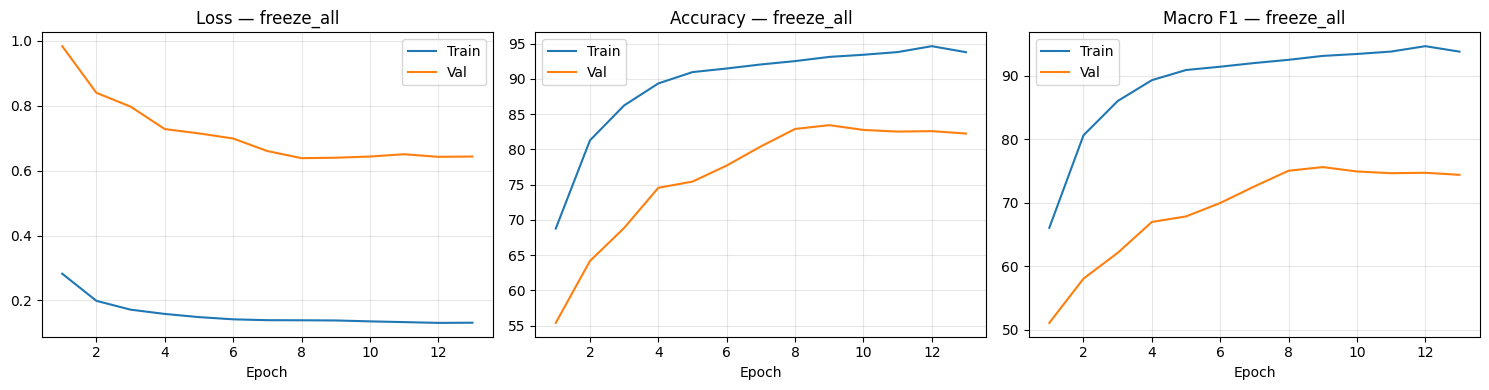

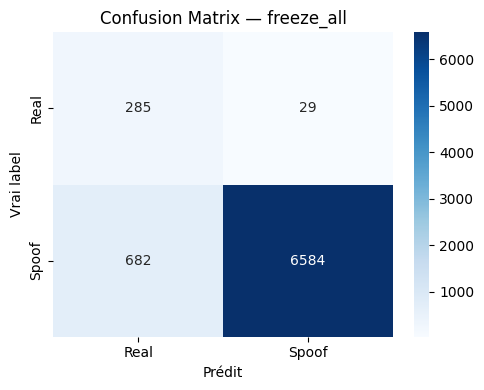

Sauvegarde Drive ignorée (Drive non disponible).


In [ ]:
# =========================
# freeze_all
# =========================
model_freeze_all, history_freeze_all, metrics_freeze_all, results_freeze_all = fit_strategy("freeze_all")

## Exécution — `1_finetune`


Début entraînement de la stratégie : 1_finetune


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841, 1024]) vs model:torch.Size([2, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


1_finetune: trainable = 25,207,362 / 86,745,274 (29.06%)

----------------------------------------------------------------------
[1_finetune] Epoch 1/15
----------------------------------------------------------------------
[1_finetune] Epoch 1/15 | Batch 1/513
[1_finetune] Epoch 1/15 | Batch 21/513
[1_finetune] Epoch 1/15 | Batch 41/513
[1_finetune] Epoch 1/15 | Batch 61/513
[1_finetune] Epoch 1/15 | Batch 81/513
[1_finetune] Epoch 1/15 | Batch 101/513
[1_finetune] Epoch 1/15 | Batch 121/513
[1_finetune] Epoch 1/15 | Batch 141/513
[1_finetune] Epoch 1/15 | Batch 161/513
[1_finetune] Epoch 1/15 | Batch 181/513
[1_finetune] Epoch 1/15 | Batch 201/513
[1_finetune] Epoch 1/15 | Batch 221/513
[1_finetune] Epoch 1/15 | Batch 241/513
[1_finetune] Epoch 1/15 | Batch 261/513
[1_finetune] Epoch 1/15 | Batch 281/513
[1_finetune] Epoch 1/15 | Batch 301/513
[1_finetune] Epoch 1/15 | Batch 321/513
[1_finetune] Epoch 1/15 | Batch 341/513
[1_finetune] Epoch 1/15 | Batch 361/513
[1_finetune] Epoch 1/1

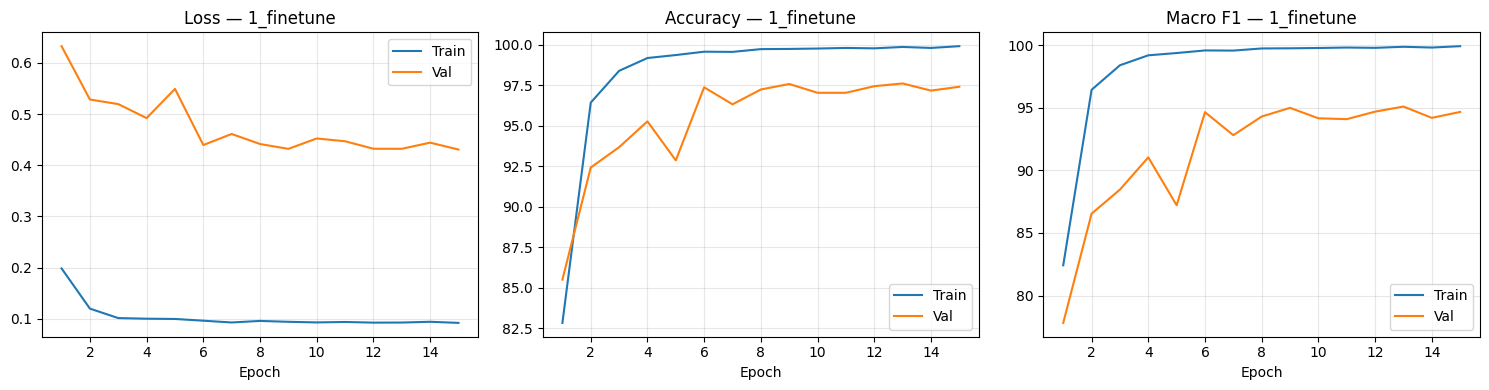

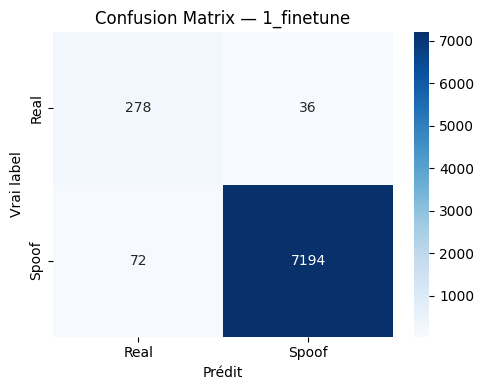

Sauvegarde Drive ignorée (Drive non disponible).


In [ ]:
# =========================
# 1_finetune
# =========================
model_1_finetune, history_1_finetune, metrics_1_finetune, results_1_finetune = fit_strategy("1_finetune")

## Exécution — `2_finetune`

In [ ]:
# =========================
# 2_finetune
# =========================
model_2_finetune, history_2_finetune, metrics_2_finetune, results_2_finetune = fit_strategy("2_finetune")

## Exécution — `3_finetune`

In [ ]:
# =========================
# 3_finetune
# =========================
model_3_finetune, history_3_finetune, metrics_3_finetune, results_3_finetune = fit_strategy("3_finetune")

## Exécution — `finetune_all`


Début entraînement de la stratégie : finetune_all


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/437M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224-in22k
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841]) vs model:torch.Size([2])            
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([21841, 1024]) vs model:torch.Size([2, 1024])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


finetune_all: trainable = 86,745,274 / 86,745,274 (100.00%)

----------------------------------------------------------------------
[finetune_all] Epoch 1/15
----------------------------------------------------------------------
[finetune_all] Epoch 1/15 | Batch 1/513
[finetune_all] Epoch 1/15 | Batch 21/513
[finetune_all] Epoch 1/15 | Batch 41/513
[finetune_all] Epoch 1/15 | Batch 61/513
[finetune_all] Epoch 1/15 | Batch 81/513
[finetune_all] Epoch 1/15 | Batch 101/513
[finetune_all] Epoch 1/15 | Batch 121/513
[finetune_all] Epoch 1/15 | Batch 141/513
[finetune_all] Epoch 1/15 | Batch 161/513
[finetune_all] Epoch 1/15 | Batch 181/513
[finetune_all] Epoch 1/15 | Batch 201/513
[finetune_all] Epoch 1/15 | Batch 221/513
[finetune_all] Epoch 1/15 | Batch 241/513
[finetune_all] Epoch 1/15 | Batch 261/513
[finetune_all] Epoch 1/15 | Batch 281/513
[finetune_all] Epoch 1/15 | Batch 301/513
[finetune_all] Epoch 1/15 | Batch 321/513
[finetune_all] Epoch 1/15 | Batch 341/513
[finetune_all] Epoch 

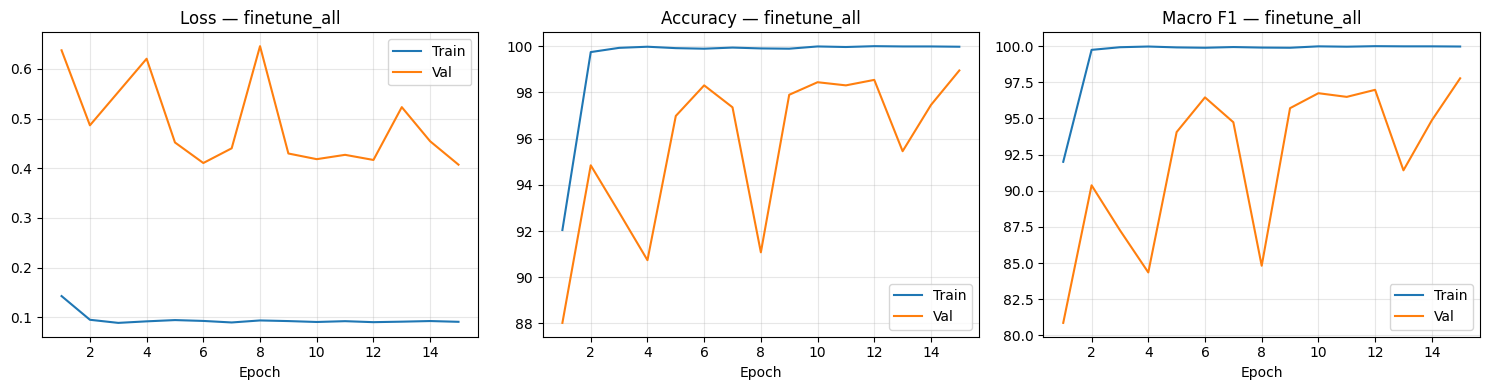

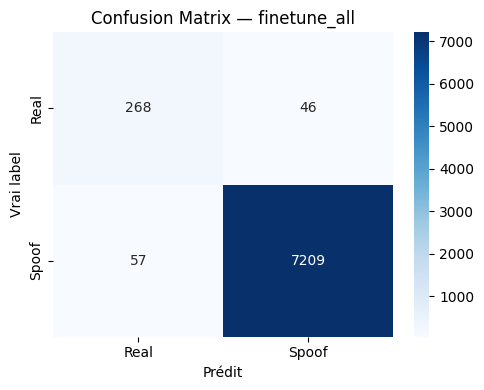

Outputs copiés vers Google Drive: /content/drive/MyDrive/outputs_swin_lccfasd/finetune_all


In [23]:
# =========================
# finetune_all
# =========================
model_finetune_all, history_finetune_all, metrics_finetune_all, results_finetune_all = fit_strategy("finetune_all")

## 14) Comparaison finale des 5 stratégies

In [ ]:
# =========================
# 14) Comparaison finale
# =========================
all_results = [
    results_freeze_all,
    results_1_finetune,
    results_2_finetune,
    results_3_finetune,
    results_finetune_all,
]

summary_df = pd.DataFrame(all_results).set_index("strategy").sort_values("f1_macro", ascending=False)
display(summary_df.round(4))

summary_df.to_csv(SAVE_ROOT / "summary_results.csv")
summary_df.to_json(SAVE_ROOT / "summary_results.json", orient="index", indent=2)

best_strategy = summary_df.index[0]
print("Meilleure stratégie selon F1 Macro :", best_strategy)
print(summary_df.loc[best_strategy])

plt.figure(figsize=(10, 5))
summary_df[["accuracy", "balanced_accuracy", "f1_macro"]].plot(kind="bar")
plt.title("Comparaison des stratégies")
plt.ylabel("Score (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(SAVE_ROOT / "summary_barplot.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
# =========================
# Evaluation détaillée
# =========================
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_detailed(model, loader, split_name="test"):
    model.eval()
    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    print(f"\n===== Evaluation détaillée : {split_name} =====")
    print("Balanced Accuracy :", balanced_accuracy_score(y_true, y_pred))
    print("F1 Macro          :", f1_score(y_true, y_pred, average="macro"))
    print("\nClassification report :")
    print(classification_report(y_true, y_pred, target_names=["real", "spoof"], digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["real", "spoof"],
                yticklabels=["real", "spoof"])
    plt.title(f"Matrice de confusion - {split_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Vrai")
    plt.show()

evaluate_detailed(model, val_loader, "val")
evaluate_detailed(model, test_loader, "test")

In [ ]:
# =========================
# 15) Compression finale des outputs
# =========================
zip_path = str(SAVE_ROOT) + ".zip"
if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(str(SAVE_ROOT), 'zip', str(SAVE_ROOT))
print('Archive créée :', zip_path)

if DRIVE_ROOT is not None:
    drive_zip = DRIVE_ROOT / Path(zip_path).name
    shutil.copy2(zip_path, drive_zip)
    print('Archive copiée vers Google Drive :', drive_zip)



KeyboardInterrupt: 

## 16) Notes importantes

### Pourquoi ce notebook est plus stable
- dataset téléchargé **automatiquement**
- détection automatique de `train / val / test`
- code séparé et lisible
- sauvegarde pour **chaque stratégie**
- métriques adaptées à un dataset **déséquilibré**
- sélection du meilleur modèle par **Macro F1**
- courbes : **loss**, **accuracy**, **Macro F1**

### Solution idéale pour ton cas
Le dataset est très déséquilibré, donc regarde surtout :
- `f1_macro`
- `balanced_accuracy`
- matrice de confusion
- recall de `real`

En général, pour ce projet :
- `1_finetune` ou `2_finetune` sont souvent les meilleurs compromis
- `finetune_all` peut donner le meilleur score brut mais parfois moins stable


In [ ]:
from pathlib import Path

zip_file = Path("/content/outputs_swin_lccfasd.zip")
print("ZIP existe :", zip_file.exists())
if zip_file.exists():
    print("Taille (MB) :", round(zip_file.stat().st_size / (1024**2), 2))

ZIP existe : True
Taille (MB) : 1850.56


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import shutil

src_dir = Path("/content/outputs_swin_lccfasd")
dst_dir = Path("/content/drive/MyDrive/Models_cv")

if not src_dir.exists():
    print("Erreur : dossier source introuvable :", src_dir)
else:
    dst_dir.mkdir(parents=True, exist_ok=True)

    for item in src_dir.rglob("*"):
        rel = item.relative_to(src_dir)
        target = dst_dir / rel

        if item.is_dir():
            target.mkdir(parents=True, exist_ok=True)
        else:
            target.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(item, target)

    print("Copie complète terminée ✅")

Copie complète terminée ✅
